In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
years = range(2013, 2024)
dfs = []

for year in years:
    temp = pd.read_csv(f"PROV_TYPE_{year}.csv")
    temp['Year'] = year
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

In [5]:
top10_types = (
    df.groupby('Rndrng_Prvdr_Type')['Rndrng_NPI']
      .nunique()
      .sort_values(ascending=False)
      .head(10)
      .index
)

print(top10_types)

Index(['APP', 'PrimaryCare', 'RehabTherapy', 'SurgeryOther', 'Anesthesia',
       'BehavioralHealth', 'MedicalSpecialtyOther', 'AcuteCare',
       'FacilitySupplierProgram', 'VisionHearing'],
      dtype='str', name='Rndrng_Prvdr_Type')


In [6]:
top10_yearly = (
    df[df['Rndrng_Prvdr_Type'].isin(top10_types)]
      .groupby(['Year','Rndrng_Prvdr_Type'])['Rndrng_NPI']
      .nunique()
      .unstack()
      .sort_index()
)

print(top10_yearly.head())

Rndrng_Prvdr_Type     APP  AcuteCare  Anesthesia  BehavioralHealth  \
Year                                                                 
2013               116830      41635       75730             52962   
2014               130512      42978       77532             54410   
2015               147360      44244       79691             55925   
2016               166234      45597       81715             57720   
2017               185849      51887       83932             58851   

Rndrng_Prvdr_Type  FacilitySupplierProgram  MedicalSpecialtyOther  \
Year                                                                
2013                                 55301                  74991   
2014                                 58792                  76728   
2015                                 60215                  78479   
2016                                 60416                  80363   
2017                                 59806                  82250   

Rndrng_Prvdr_Type  Primar

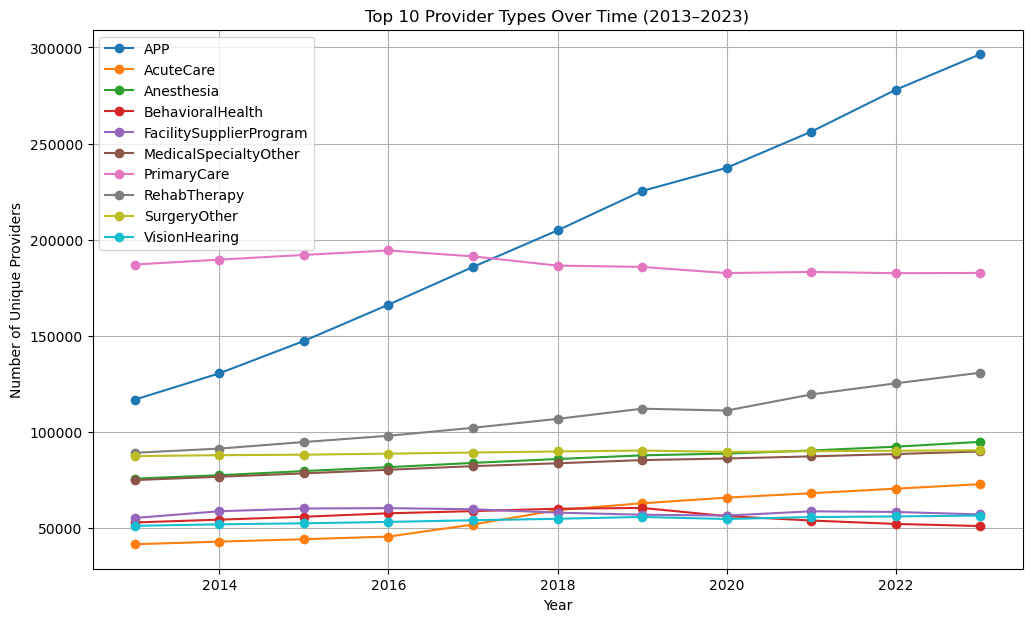

In [7]:
plt.figure(figsize=(12,7))

for col in top10_yearly.columns:
    plt.plot(top10_yearly.index,
             top10_yearly[col],
             marker='o',
             label=col)

plt.xlabel("Year")
plt.ylabel("Number of Unique Providers")
plt.title("Top 10 Provider Types Over Time (2013–2023)")
plt.legend()
plt.grid(True)
plt.show()